## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy
from statsmodels.nonparametric.smoothers_lowess import lowess 


In [2]:
notes = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/notes-20240501-20240531.parquet')
ratings = pd.read_parquet('~/Documents/GitHub/494-user-trajectories/students/ryder/ratings-20240501-20240531.parquet')
party = pd.read_csv('~/Documents/GitHub/494-user-trajectories/students/ryder/database_replication.csv')

In [3]:
party = party.replace({'party': {'republican': -1, 'democrat': 1, 'unknown': np.nan}})
party.head(10)

/var/folders/14/04j_x_597gg_sc6gcvkrz1wr0000gp/T/ipykernel_46887/3990733836.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  party = party.replace({'party': {'republican': -1, 'democrat': 1, 'unknown': np.nan}})


,Unnamed: 0,note_id,note_published_helpful,tweet_author_id,party,party_barbera,party_mosleh,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,0,1783179305159200982,0,1074480192,-1.0,republican,republican,unknown,15.110518,10.074158,1.0,1783159712986382830,politics,True,False,False,False
1,1,1783181538789605871,0,1221462414744596483,1.0,democrat,republican,democrat,13.407987,11.571043,1.0,1783171851818021181,politics,True,False,False,False
2,2,1783182562279494134,0,1291802729438945280,NaN,unknown,unknown,unknown,10.792633,7.657283,1.0,1783154445682979015,politics,True,False,False,False
3,3,1780256247847248236,0,185809250,1.0,democrat,democrat,unknown,11.642374,11.014852,0.0,1779984568143282686,science,False,False,True,False
4,4,1701837464359624879,0,890061634181373952,-1.0,republican,republican,unknown,14.037493,9.487745,1.0,1701643915659731323,politics,True,False,False,False
5,5,1763005074870259781,0,15448383,-1.0,democrat,republican,republican,15.172827,14.061444,1.0,1762789289035751782,politics,True,True,False,False
6,6,1764592373097722103,0,1468707946016219141,NaN,unknown,unknown,unknown,10.010187,9.663643,0.0,1764354551086288946,other,False,False,False,False
7,7,1653518980357967873,0,918723043798560768,NaN,unknown,unknown,unknown,10.907221,11.048156,1.0,1653295426697846784,other,False,False,False,False
8,8,1671604373598900225,0,17158189,1.0,democrat,democrat,unknown,12.222054,11.158890,0.0,1671531030530883584,other,False,False,False,False
9,9,1763035751002808656,0,1058520120,1.0,democrat,democrat,unknown,13.487619,9.447860,1.0,1762967617764004242,politics,True,True,False,False


In [4]:
notes.head()

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAtDt,noteCreatedAtDt,ratingCreatedAtDt,helpfulnessLevel,fromNotification,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor
0,1795373016215327101,1795084317133025630,46BEE7BDF0D74F67A6FB96A89554FAADC98D1C08A97888...,F6700CE6C398D88F68989BD0B4936602C790E4F7DAA7C6...,2024-05-27 13:27:06.915,2024-05-28 08:34:18.142,2024-05-30 00:14:51.014,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.449701,-0.172285
1,1794533810723492332,1794325036469506252,E57589E18ACF953A30920C3CFECAC27DC5823B4C0D6984...,None,2024-05-25 11:10:00.298,NaT,2024-05-26 10:17:57.926,HELPFUL,False,CURRENTLY_RATED_NOT_HELPFUL,-0.118752,0.028724
2,1794234926071529505,1794132104902512852,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,29B9492DE7045B4DDF4F7BB953C4FB3437C371D2BA372C...,2024-05-24 22:23:21.828,2024-05-25 05:11:56.302,2024-05-27 12:32:37.248,HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.481177,-0.097937
3,1795529392262631789,1795364492064202867,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,None,2024-05-28 08:00:25.824,NaT,2024-05-31 10:04:27.233,HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.484249,0.042055
4,1795600864155197800,1795492798986408332,C5BB45A76FD26CA3A6003E50FE3C6D086F4F4E8B44E244...,7F16863BE3FB87264952B6B64F80825EDA9544AAAC92BB...,2024-05-28 16:30:16.578,2024-05-28 23:39:41.322,2024-05-29 16:18:50.805,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,0.432479,-0.026333


In [5]:
ratings.head()

,noteAuthorParticipantId,noteId,tweetId,classification,summary,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor
0,AE392472D289E0D7728EED0EBDCEDCA116B415EC305276...,1790028118293467340,1.789931e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Das Bundesamt präsentierte eine Vielzahl von B...,NEEDS_MORE_RATINGS,0.173358,-0.630036
1,09AB0CDEA3F716BC1833EAFAD0F3DF975123175E52D8D2...,1777068928692637834,1.775209e+18,NOT_MISLEADING,It isn’t known if by “history” he’s referring ...,NEEDS_MORE_RATINGS,0.027390,0.515722
2,43147E26944271986AB001D4D545EBB9E19C7DD37AA78C...,1682287551766298624,1.680854e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This video has nothing to do with the Kerch Br...,NEEDS_MORE_RATINGS,0.073005,0.372383
3,None,1789327714673209371,NaN,None,None,NEEDS_MORE_RATINGS,0.275326,0.014137
4,46AFC1EFCB8EBC0BF2785B048A63D9FF9C5F95C926D899...,1792891972048547943,1.792834e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,資産家等を騙る詐欺が横行しており、 公釈(コミュニティノート)が必要です ○記事 ...,NEEDS_MORE_RATINGS,0.219755,0.197646


In [6]:
notes_party = notes.merge(party, left_on='noteId', right_on='note_id')
notes_party.head()

,noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAtDt,noteCreatedAtDt,ratingCreatedAtDt,helpfulnessLevel,fromNotification,noteFinalRatingStatus,...,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,1794234926071529505,1794132104902512852,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,29B9492DE7045B4DDF4F7BB953C4FB3437C371D2BA372C...,2024-05-24 22:23:21.828,2024-05-25 05:11:56.302,2024-05-27 12:32:37.248,HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,unknown,12.084831,10.923255,1.0,1794132104902512852,other,False,False,False,False
1,1795529392262631789,1795364492064202867,3A4F48380746ECBCF247F6B984F19C5D12104A444263F1...,None,2024-05-28 08:00:25.824,NaT,2024-05-31 10:04:27.233,HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,democrat,14.918422,9.299450,1.0,1795364492064202867,other,False,False,False,False
2,1795600864155197800,1795492798986408332,C5BB45A76FD26CA3A6003E50FE3C6D086F4F4E8B44E244...,7F16863BE3FB87264952B6B64F80825EDA9544AAAC92BB...,2024-05-28 16:30:16.578,2024-05-28 23:39:41.322,2024-05-29 16:18:50.805,SOMEWHAT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,unknown,11.564369,10.140061,1.0,1795492798986408332,science,False,False,True,False
3,1785504509424554406,1785345111640986045,9DE991B56C65F11A1703B4B6236D48D75E135502104D64...,41B45A48BAF1EB9AAEC2BE5F9EA4ED8ED6775FBC951FFF...,2024-04-30 16:26:59.380,2024-05-01 03:00:22.773,2024-05-01 19:25:33.859,NOT_HELPFUL,False,CURRENTLY_RATED_HELPFUL,...,republican,13.329989,9.885578,1.0,1785345111640986045,other,False,False,False,False
4,1796225083310260479,1796217517859303915,9DE991B56C65F11A1703B4B6236D48D75E135502104D64...,82DFE8A45E56FDCA96B074AB24CECF647169038ED99C21...,2024-05-30 16:30:03.022,2024-05-30 17:00:06.769,2024-05-30 17:03:59.741,SOMEWHAT_HELPFUL,False,NEEDS_MORE_RATINGS,...,republican,13.810563,10.025263,1.0,1796217517859303915,health,False,True,False,False


In [7]:
ratings_party = ratings.merge(party, left_on='noteId', right_on='note_id')
ratings_party.head()

,noteAuthorParticipantId,noteId,tweetId,classification,summary,noteFinalRatingStatus,noteFinalIntercept,noteFinalFactor,Unnamed: 0,note_id,...,party_gpt,log_followers,log_tweet,verified,tweet_id,topic,politics,health,science,economy
0,43147E26944271986AB001D4D545EBB9E19C7DD37AA78C...,1682287551766298624,1.680854e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This video has nothing to do with the Kerch Br...,NEEDS_MORE_RATINGS,0.073005,0.372383,39425,1682287551766298624,...,unknown,7.100027,8.943506,1.0,1680853788930834432,other,False,False,False,False
1,37AD81DBA55B02FD2BB7175E12C8ABAE2F632C4F52375F...,1781707174986547416,1.781668e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Ministry of Railways is trying to mislead peop...,CURRENTLY_RATED_HELPFUL,0.522933,-0.200378,14707,1781707174986547416,...,unknown,15.972264,13.436999,1.0,1781668094852595736,science,False,False,True,False
2,800DBAAA5E49D8D989D1530CFB044C5AC57D4B382460F8...,1786484395236294934,1.786458e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,This was not said by Tesla Board Of Directors ...,NEEDS_MORE_RATINGS,0.234975,0.362661,141048,1786484395236294934,...,unknown,6.588926,8.461680,1.0,1786457583085044044,economy,False,False,True,True
3,13B9C99438A7ED95730D15D8A17FF2730D5277F6F3D17F...,1787041791188885705,1.787003e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,Keir Starmer has NEVER said &quot;so long as...,NEEDS_MORE_RATINGS,0.051909,0.131454,31969,1787041791188885705,...,unknown,12.438045,11.505075,1.0,1787002554817114221,politics,True,False,False,False
4,531E46A7737D5F15F23D18984345B890F0E6F23ECD04F0...,1793760872466108827,1.793693e+18,MISINFORMED_OR_POTENTIALLY_MISLEADING,"This tip, even when it works, is far from bein...",NEEDS_MORE_RATINGS,-0.048518,-0.034436,201383,1793760872466108827,...,democrat,14.729246,10.722739,1.0,1793693381849145726,science,False,False,True,False


## Signals

### Partisanship Signals

In [8]:
### Partisanship Signals ###

# Average party for authors of tweets they wrote notes about (encode republican as -1 and democrat as 1).
avg_party_tweet_author = notes_party.groupby('noteAuthorParticipantId')['party'].mean()

# Average party for authors of tweets where they rated the note helpful
avg_party_tweet_author_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')].groupby('raterParticipantId')['party'].mean()
# Average party for authors of tweets where they rated the note not helpful
avg_party_tweet_author_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')].groupby('raterParticipantId')['party'].mean()

# Average note factor of notes they rated helpful
avg_note_factor_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL')].groupby('raterParticipantId')['noteFinalFactor'].mean()
# Average note factor of notes they rated not helpful
avg_note_factor_not_helpful = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL')].groupby('raterParticipantId')['noteFinalFactor'].mean()

# Percent of authors of tweets they wrote notes about that were republican
tweet_auth_rep = notes_party['party'] == -1
pct_tweet_auth_rep_noted = tweet_auth_rep.groupby(notes_party['noteAuthorParticipantId']).mean() * 100

# Percent of authors of tweets that were republican for posts they rated helpful
pct_auth_tweet_rep_helpful = tweet_auth_rep.groupby(notes_party[notes_party['helpfulnessLevel'] == 'HELPFUL']['raterParticipantId']).mean() * 100
# Percent of authors of tweets that were republican for posts they rated not helpful
pct_auth_tweet_rep_not_helpful = tweet_auth_rep.groupby(notes_party[notes_party['helpfulnessLevel'] == 'NOT_HELPFUL']['raterParticipantId']).mean() * 100


### Interests Signals

In [9]:
### Interests Signals ###

# Number of unique topics written about
num_unique_topics_noted = notes_party.groupby('noteAuthorParticipantId')['topic'].nunique()

#Number of unique topics rated
num_unique_topics_rated = notes_party.groupby('raterParticipantId')['topic'].nunique()

# Shannon entropy for topics of posts they rated
topic_entropy_noted = notes_party.groupby('noteAuthorParticipantId')['topic'].apply(lambda x: entropy(x.value_counts(normalize=True), base=2))

# Shannon entropy for topics of posts they wrote notes for
topic_entropy_rated = notes_party.groupby('raterParticipantId')['topic'].apply(lambda x: entropy(x.value_counts(normalize=True), base=2))


### Skills Signals

In [10]:
### Skills Signals ###

# Average note intercept for notes they wrote
avg_note_intercept = notes_party.groupby('noteAuthorParticipantId')['noteFinalIntercept'].mean()

# Percent of notes they wrote that earned "helpful" rating
helpful_notes = notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_HELPFUL"
pct_helpful_notes = helpful_notes.groupby(notes_party['noteAuthorParticipantId']).mean()

# Percent of ratings they gave where their rating agreed with the helpfulness the post went on to earn
rated_helpful = (((notes_party['helpfulnessLevel'] == "HELPFUL") & (notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_HELPFUL")) | 
                 ((notes_party['helpfulnessLevel'] == "NOT_HELPFUL") & 
                  ((notes_party['noteFinalRatingStatus'] == "CURRENTLY_RATED_NOT_HELPFUL") |
                  (notes_party['noteFinalRatingStatus'] == "NEEDS_MORE_RATINGS"))
                 ))
pct_correct_ratings = rated_helpful.groupby(notes_party['raterParticipantId']).mean()
rated_helpful.head()

0     True
1     True
2    False
3    False
4    False
dtype: bool

## Questions

### 1. Does partisanship as measured through note factors align with partisanship as measured through the external data I sent you (from the trenault GitHub)?

It appears so, for the most part. A majority of tweets measured as 'republican' or 'democrat' had a final note factor above/below +/-0.4, and the unknowns are clustered around 0. It does however appear that there is a relatively small grouping of assessed 'democrat' tweets with a note factor resembling the distribution of the 'republican' tweets, but this is not replicated on the republican side. Interesting.

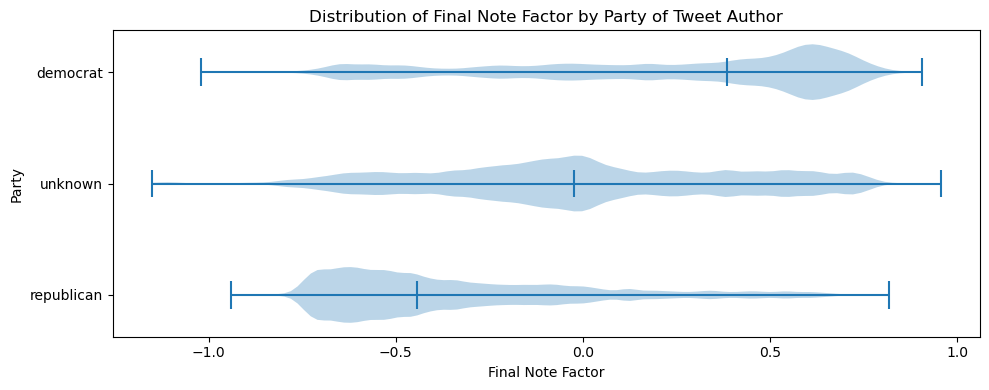

In [11]:
# Violin plot: party category (y) vs noteFinalFactor (x)
violin_df = notes_party[['party', 'noteFinalFactor']].dropna(subset=['noteFinalFactor']).copy()
violin_df['party_cat'] = violin_df['party'].map({-1: 'republican', 1: 'democrat'}).fillna('unknown')

order = ['republican', 'unknown', 'democrat']
data = [violin_df.loc[violin_df['party_cat'] == c, 'noteFinalFactor'].values for c in order]

fig, ax = plt.subplots(figsize=(10, 4))
ax.violinplot(data, vert=False, showmedians=True)

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order)
ax.set_xlabel('Final Note Factor')
ax.set_ylabel('Party')
ax.set_title('Distribution of Final Note Factor by Party of Tweet Author')
plt.tight_layout()
plt.show()

### 2. What is the relationship between how frequently a user contributes and their partisanship?

Doing a simple linear regression, it looks like there is no strong relationship between the frequency of note-writing and partisanship.

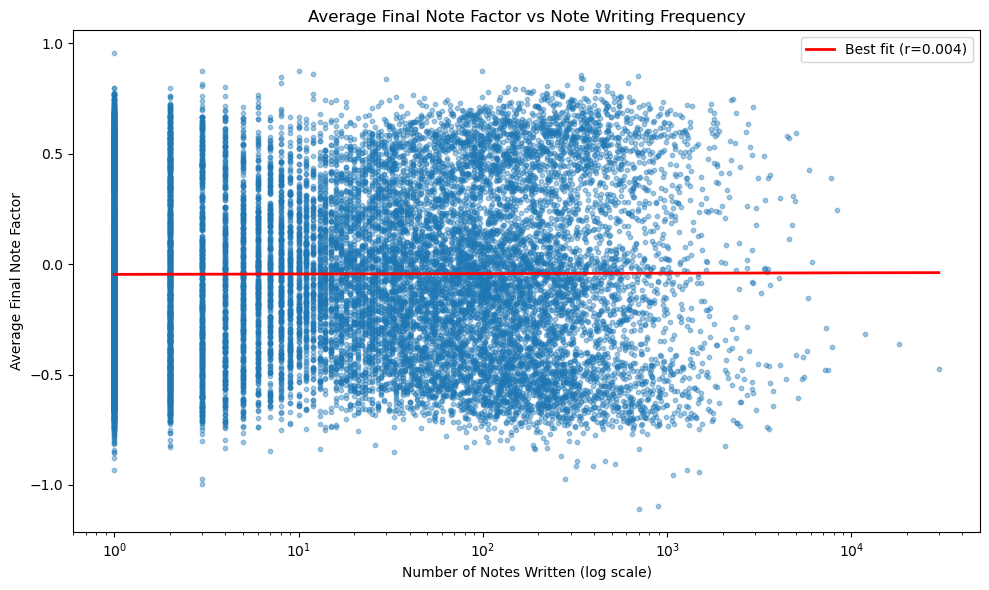

In [12]:
# Create scatter plot of average final note factor by author vs note writing frequency
fig, ax = plt.subplots(figsize=(10, 6))

# Note writing frequency per author
freq_noted_filtered = notes_party.groupby('noteAuthorParticipantId')['noteId'].count()
freq_noted_filtered = freq_noted_filtered[freq_noted_filtered >= 1]

# Average final note factor per author
avg_note_factor_by_author = notes_party.groupby('noteAuthorParticipantId')['noteFinalFactor'].mean()

# Merge without absolute value
df_scatter = pd.DataFrame({
    'freq': freq_noted_filtered,
    'avg_note_factor': avg_note_factor_by_author
}).dropna()

# Scatter plot
ax.scatter(df_scatter['freq'], df_scatter['avg_note_factor'], s=10, alpha=0.4)

# Line of best fit (log freq)
log_freq = np.log(df_scatter['freq'])
m, b = np.polyfit(log_freq, df_scatter['avg_note_factor'], 1)
r = np.corrcoef(log_freq, df_scatter['avg_note_factor'])[0, 1]

xs = np.logspace(np.log10(df_scatter['freq'].min()), np.log10(df_scatter['freq'].max()), 200)
ax.plot(xs, m * np.log(xs) + b, color='red', lw=2, label=f'Best fit (r={r:.3f})')

ax.set_xscale('log')
ax.set_xlabel('Number of Notes Written (log scale)')
ax.set_ylabel('Average Final Note Factor')
ax.set_title('Average Final Note Factor vs Note Writing Frequency')
ax.legend()
plt.tight_layout()
plt.show()

But looking closer, there appear to be three distinct tendencies within this graph as the number of notes written increases. Breaking out each component to compare contributors with a high, neutral, or low average final note factor, we can see that there is a positive correlation between higher frequency and higher partisanship within the two outside groups, while there is very little correlation for the middle group.

Low factor (< -0.25): 3727 authors
Neutral (-0.25 to 0.25): 4614 authors
High factor (> 0.25): 2893 authors
Total: 11234 authors


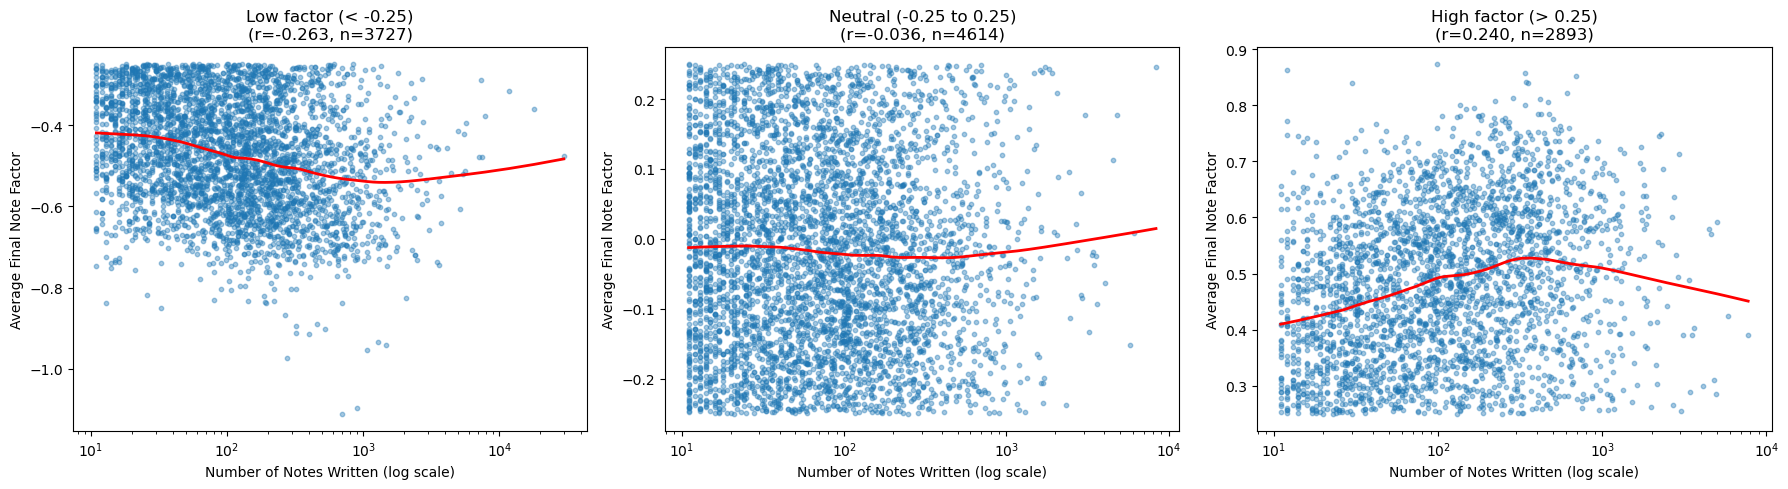

In [13]:
# Split data into three groups based on average final note factor
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Note writing frequency per author
freq_noted = notes_party.groupby('noteAuthorParticipantId')['noteId'].count()
avg_note_factor_by_author = notes_party.groupby('noteAuthorParticipantId')['noteFinalFactor'].mean()

df_scatter = pd.DataFrame({
    'freq': freq_noted,
    'avg_note_factor': avg_note_factor_by_author
}).dropna()

# Filter for authors with more than 10 notes
df_scatter = df_scatter[df_scatter['freq'] > 10]

# Split into three groups
df_low = df_scatter[df_scatter['avg_note_factor'] < -0.25]
df_mid = df_scatter[(df_scatter['avg_note_factor'] >= -0.25) & (df_scatter['avg_note_factor'] <= 0.25)]
df_high = df_scatter[df_scatter['avg_note_factor'] > 0.25]

# Function to plot with LOESS curve
def plot_group(ax, df, title, frac=0.35):
    if len(df) > 0:
        ax.scatter(df['freq'], df['avg_note_factor'], s=10, alpha=0.4)

        if len(df) > 5:
            log_freq = np.log(df['freq'].values)
            y = df['avg_note_factor'].values

            smooth = lowess(y, log_freq, frac=frac, it=0, return_sorted=True)
            ax.plot(np.exp(smooth[:, 0]), smooth[:, 1], color='red', lw=2, label='LOESS')

            r = np.corrcoef(log_freq, y)[0, 1]
            ax.set_title(f'{title}\n(r={r:.3f}, n={len(df)})')
        else:
            ax.set_title(f'{title}\n(n={len(df)})')

        ax.set_xscale('log')
        ax.set_xlabel('Number of Notes Written (log scale)')
        ax.set_ylabel('Average Final Note Factor')

# Plot each group
plot_group(axes[0], df_low, 'Low factor (< -0.25)')
plot_group(axes[1], df_mid, 'Neutral (-0.25 to 0.25)')
plot_group(axes[2], df_high, 'High factor (> 0.25)')

# Print counts
print(f"Low factor (< -0.25): {len(df_low)} authors")
print(f"Neutral (-0.25 to 0.25): {len(df_mid)} authors")
print(f"High factor (> 0.25): {len(df_high)} authors")
print(f"Total: {len(df_scatter)} authors")

plt.tight_layout()
plt.show()

### 3. Do users systematically rate one side helpful and the other not helpful?

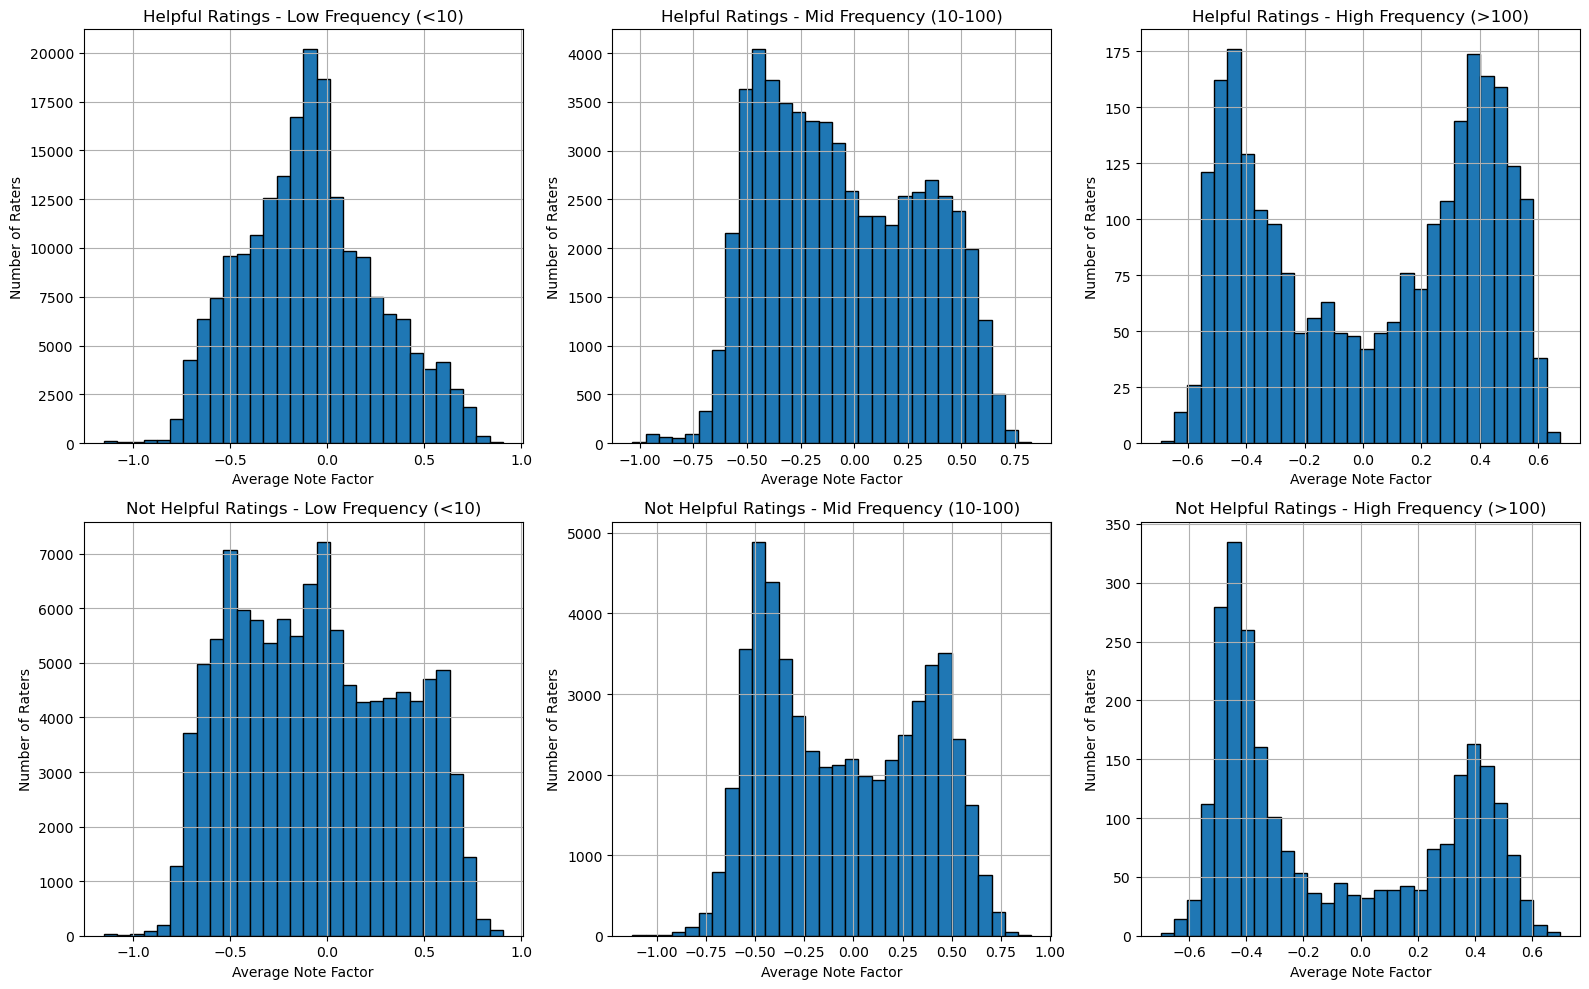

In [14]:
# layout
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# frequency masks
mask_low = notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 100)
mask_high = notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 100

# Helpful ratings by frequency
avg_note_factor_helpful_low = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_low].groupby('raterParticipantId')['noteFinalFactor'].mean()
avg_note_factor_helpful_mid = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_mid].groupby('raterParticipantId')['noteFinalFactor'].mean()
avg_note_factor_helpful_high = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_high].groupby('raterParticipantId')['noteFinalFactor'].mean()

# Not helpful ratings by frequency
avg_note_factor_not_helpful_low = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_low].groupby('raterParticipantId')['noteFinalFactor'].mean()
avg_note_factor_not_helpful_mid = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_mid].groupby('raterParticipantId')['noteFinalFactor'].mean()
avg_note_factor_not_helpful_high = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_high].groupby('raterParticipantId')['noteFinalFactor'].mean()

# Plot helpful ratings
avg_note_factor_helpful_low.hist(ax=axes[0, 0], bins=30, edgecolor='black')
axes[0, 0].set_title('Helpful Ratings - Low Frequency (<10)')
axes[0, 0].set_xlabel('Average Note Factor')
axes[0, 0].set_ylabel('Number of Raters')

avg_note_factor_helpful_mid.hist(ax=axes[0, 1], bins=30, edgecolor='black')
axes[0, 1].set_title('Helpful Ratings - Mid Frequency (10-100)')
axes[0, 1].set_xlabel('Average Note Factor')
axes[0, 1].set_ylabel('Number of Raters')

avg_note_factor_helpful_high.hist(ax=axes[0, 2], bins=30, edgecolor='black')
axes[0, 2].set_title('Helpful Ratings - High Frequency (>100)')
axes[0, 2].set_xlabel('Average Note Factor')
axes[0, 2].set_ylabel('Number of Raters')

# Plot not helpful ratings
avg_note_factor_not_helpful_low.hist(ax=axes[1, 0], bins=30, edgecolor='black')
axes[1, 0].set_title('Not Helpful Ratings - Low Frequency (<10)')
axes[1, 0].set_xlabel('Average Note Factor')
axes[1, 0].set_ylabel('Number of Raters')

avg_note_factor_not_helpful_mid.hist(ax=axes[1, 1], bins=30, edgecolor='black')
axes[1, 1].set_title('Not Helpful Ratings - Mid Frequency (10-100)')
axes[1, 1].set_xlabel('Average Note Factor')
axes[1, 1].set_ylabel('Number of Raters')

avg_note_factor_not_helpful_high.hist(ax=axes[1, 2], bins=30, edgecolor='black')
axes[1, 2].set_title('Not Helpful Ratings - High Frequency (>100)')
axes[1, 2].set_xlabel('Average Note Factor')
axes[1, 2].set_ylabel('Number of Raters')

plt.tight_layout()
plt.show()

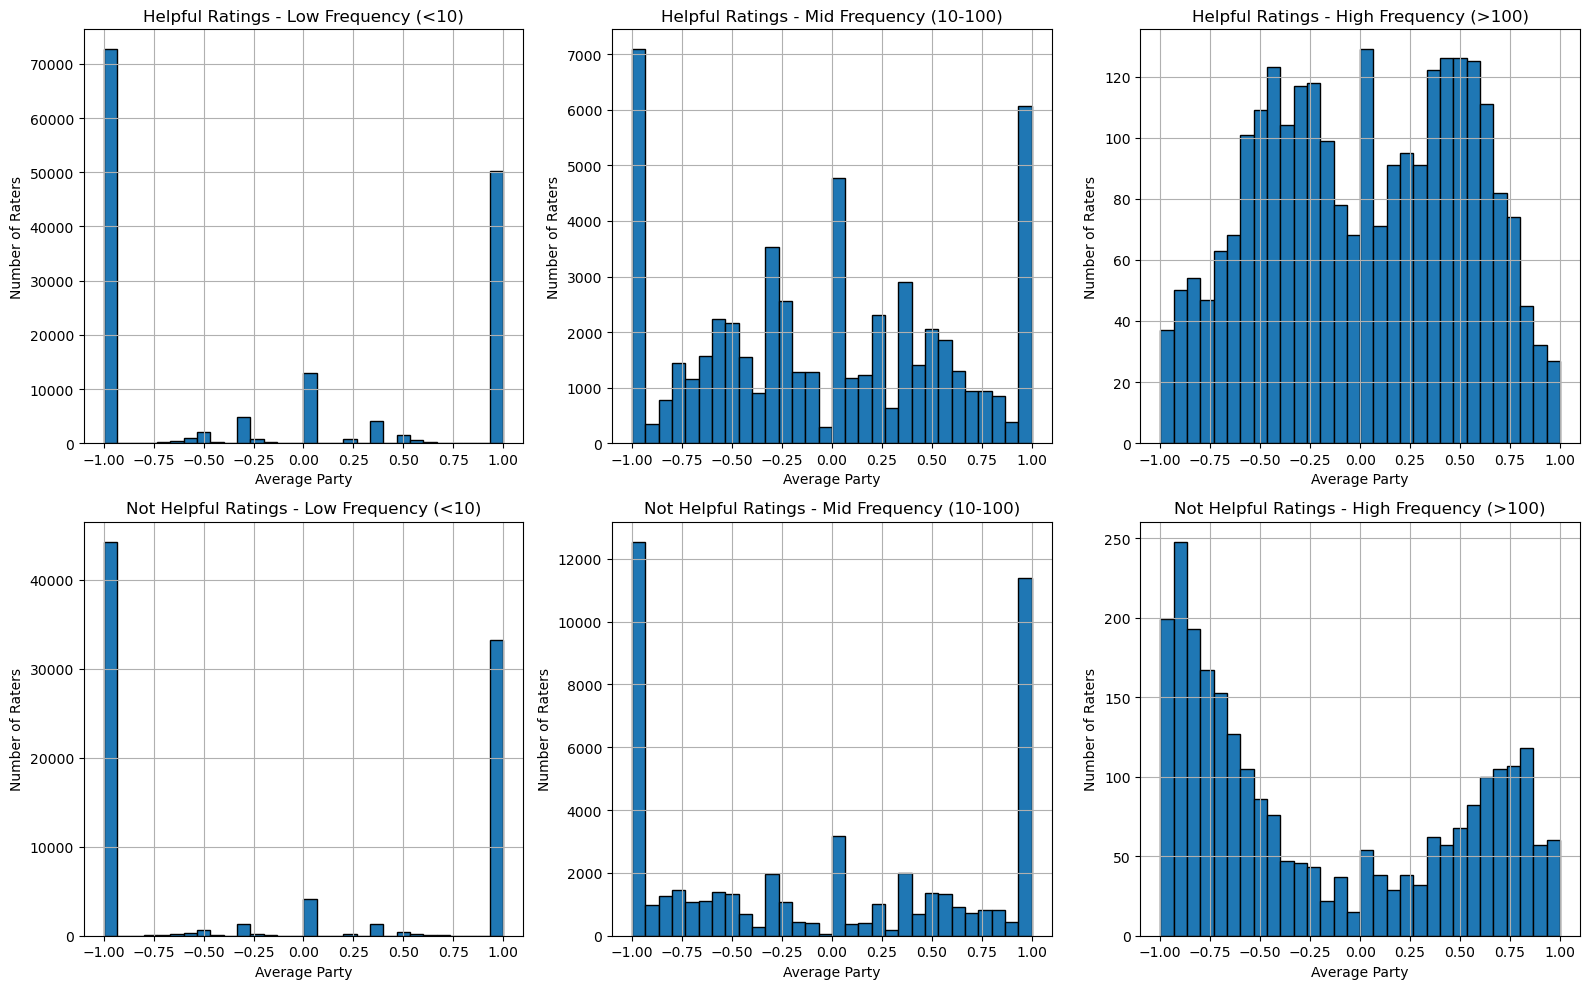

In [15]:
# layout
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# frequency masks
mask_low = notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 100)
mask_high = notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 100

# Helpful ratings by frequency
avg_party_helpful_low = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_low].groupby('raterParticipantId')['party'].mean()
avg_party_helpful_mid = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_mid].groupby('raterParticipantId')['party'].mean()
avg_party_helpful_high = notes_party[(notes_party['helpfulnessLevel'] == 'HELPFUL') & mask_high].groupby('raterParticipantId')['party'].mean()

# Not helpful ratings by frequency
avg_party_not_helpful_low = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_low].groupby('raterParticipantId')['party'].mean()
avg_party_not_helpful_mid = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_mid].groupby('raterParticipantId')['party'].mean()
avg_party_not_helpful_high = notes_party[(notes_party['helpfulnessLevel'] == 'NOT_HELPFUL') & mask_high].groupby('raterParticipantId')['party'].mean()

# Plot helpful ratings
avg_party_helpful_low.hist(ax=axes[0, 0], bins=30, edgecolor='black')
axes[0, 0].set_title('Helpful Ratings - Low Frequency (<10)')
axes[0, 0].set_xlabel('Average Party')
axes[0, 0].set_ylabel('Number of Raters')

avg_party_helpful_mid.hist(ax=axes[0, 1], bins=30, edgecolor='black')
axes[0, 1].set_title('Helpful Ratings - Mid Frequency (10-100)')
axes[0, 1].set_xlabel('Average Party')
axes[0, 1].set_ylabel('Number of Raters')

avg_party_helpful_high.hist(ax=axes[0, 2], bins=30, edgecolor='black')
axes[0, 2].set_title('Helpful Ratings - High Frequency (>100)')
axes[0, 2].set_xlabel('Average Party')
axes[0, 2].set_ylabel('Number of Raters')

# Plot not helpful ratings
avg_party_not_helpful_low.hist(ax=axes[1, 0], bins=30, edgecolor='black')
axes[1, 0].set_title('Not Helpful Ratings - Low Frequency (<10)')
axes[1, 0].set_xlabel('Average Party')
axes[1, 0].set_ylabel('Number of Raters')

avg_party_not_helpful_mid.hist(ax=axes[1, 1], bins=30, edgecolor='black')
axes[1, 1].set_title('Not Helpful Ratings - Mid Frequency (10-100)')
axes[1, 1].set_xlabel('Average Party')
axes[1, 1].set_ylabel('Number of Raters')

avg_party_not_helpful_high.hist(ax=axes[1, 2], bins=30, edgecolor='black')
axes[1, 2].set_title('Not Helpful Ratings - High Frequency (>100)')
axes[1, 2].set_xlabel('Average Party')
axes[1, 2].set_ylabel('Number of Raters')

plt.tight_layout()
plt.show()

### 4. Do users who rate one side helpful and the other side not helpful tend to have a difference in how frequently they rate notes from each side?

Still working on this.

### 5. Do users tend to focus on a single topic, or do they tend to mix topics?

Most contributors who have rated more than one note 

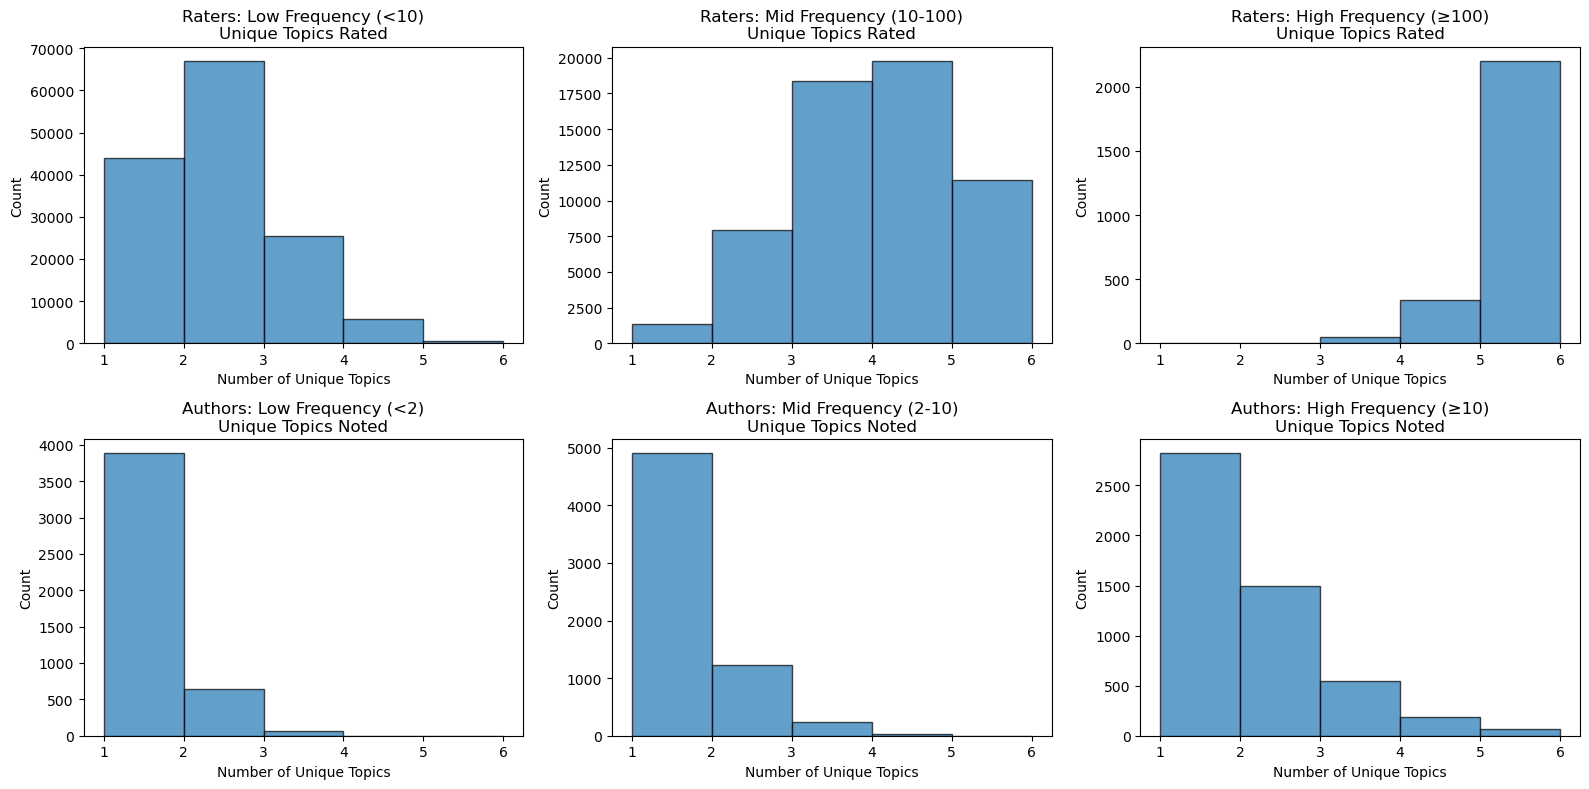

In [16]:
# filter for raters/authors with more than 1 contribution
mask_rated = notes_party.groupby('raterParticipantId')['noteId'].transform('count') > 1
mask_noted = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') > 1

# frequency and unique topic counts
freq_rated = notes_party[mask_rated].groupby('raterParticipantId')['noteId'].count()
freq_noted = notes_party[mask_noted].groupby('noteAuthorParticipantId')['noteId'].count()

num_unique_topics_rated = notes_party[mask_rated].groupby('raterParticipantId')['topic'].nunique()
num_unique_topics_noted = notes_party[mask_noted].groupby('noteAuthorParticipantId')['topic'].nunique()

# frequency masks
mask_rated_low = freq_rated < 10
mask_rated_mid = (freq_rated >= 10) & (freq_rated < 100)
mask_rated_high = freq_rated >= 100

mask_noted_low = freq_noted < 10
mask_noted_mid = (freq_noted >= 10) & (freq_noted < 100)
mask_noted_high = freq_noted >= 100

# histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# raters
axes[0, 0].hist(num_unique_topics_rated[mask_rated_low], bins=range(1, num_unique_topics_rated.max() + 2), edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Raters: Low Frequency (<10)\nUnique Topics Rated')
axes[0, 0].set_xlabel('Number of Unique Topics')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(num_unique_topics_rated[mask_rated_mid], bins=range(1, num_unique_topics_rated.max() + 2), edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Raters: Mid Frequency (10-100)\nUnique Topics Rated')
axes[0, 1].set_xlabel('Number of Unique Topics')
axes[0, 1].set_ylabel('Count')

axes[0, 2].hist(num_unique_topics_rated[mask_rated_high], bins=range(1, num_unique_topics_rated.max() + 2), edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Raters: High Frequency (≥100)\nUnique Topics Rated')
axes[0, 2].set_xlabel('Number of Unique Topics')
axes[0, 2].set_ylabel('Count')

# authors
axes[1, 0].hist(num_unique_topics_noted[mask_noted_low], bins=range(1, num_unique_topics_noted.max() + 2), edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Authors: Low Frequency (<2)\nUnique Topics Noted')
axes[1, 0].set_xlabel('Number of Unique Topics')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(num_unique_topics_noted[mask_noted_mid], bins=range(1, num_unique_topics_noted.max() + 2), edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Authors: Mid Frequency (2-10)\nUnique Topics Noted')
axes[1, 1].set_xlabel('Number of Unique Topics')
axes[1, 1].set_ylabel('Count')

axes[1, 2].hist(num_unique_topics_noted[mask_noted_high], bins=range(1, num_unique_topics_noted.max() + 2), edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Authors: High Frequency (≥10)\nUnique Topics Noted')
axes[1, 2].set_xlabel('Number of Unique Topics')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

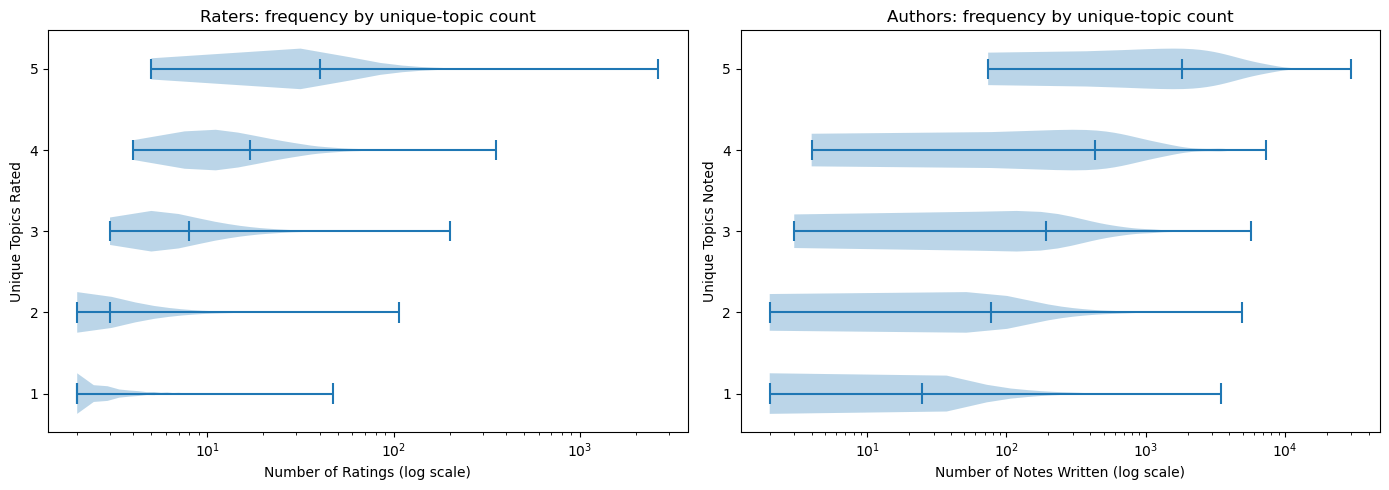

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask_rated = notes_party.groupby('raterParticipantId')['noteId'].transform('count') > 1
num_unique_topics_rated_filtered = notes_party[mask_rated].groupby('raterParticipantId')['topic'].nunique()

mask_noted = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') > 1
num_unique_topics_noted_filtered = notes_party[mask_noted].groupby('noteAuthorParticipantId')['topic'].nunique()

plt.tight_layout()

freq_rated = notes_party[mask_rated].groupby('raterParticipantId')['noteId'].count()
freq_noted = notes_party[mask_noted].groupby('noteAuthorParticipantId')['noteId'].count()

df_rated = pd.DataFrame({
    'freq': freq_rated,
    'unique_topics': num_unique_topics_rated_filtered
}).dropna()

df_noted = pd.DataFrame({
    'freq': freq_noted,
    'unique_topics': num_unique_topics_noted_filtered
}).dropna()

cats_r = sorted(df_rated['unique_topics'].unique())
data_r = [df_rated.loc[df_rated['unique_topics'] == c, 'freq'].values for c in cats_r]

cats_n = sorted(df_noted['unique_topics'].unique())
data_n = [df_noted.loc[df_noted['unique_topics'] == c, 'freq'].values for c in cats_n]

parts = axes[0].violinplot(data_r, showmeans=False, showmedians=True, vert=False, positions=range(1, len(cats_r) + 1))
axes[0].set_yticks(range(1, len(cats_r) + 1))
axes[0].set_yticklabels(cats_r)
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Ratings (log scale)')
axes[0].set_ylabel('Unique Topics Rated')
axes[0].set_title('Raters: frequency by unique-topic count')

parts = axes[1].violinplot(data_n, showmeans=False, showmedians=True, vert=False, positions=range(1, len(cats_n) + 1))
axes[1].set_yticks(range(1, len(cats_n) + 1))
axes[1].set_yticklabels(cats_n)
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Notes Written (log scale)')
axes[1].set_ylabel('Unique Topics Noted')
axes[1].set_title('Authors: frequency by unique-topic count')

plt.tight_layout()

### 6. What is the relationship between how frequently users contribute and what topics they focus on?

Comparing low-, medium-, and high-frequency note-raters, there is a clear increase in focus on politics-related tweets as rating frequency increases. "science" and "other" seem to decrease as rating frequency increases, and "health" appears to increase a bit. Applying the same analysis to note-writing, we can observe a similar pattern of politics increasing in relative frequency while everything else stays fairly even across contribution frequency, but the change is not nearly as pronounced.

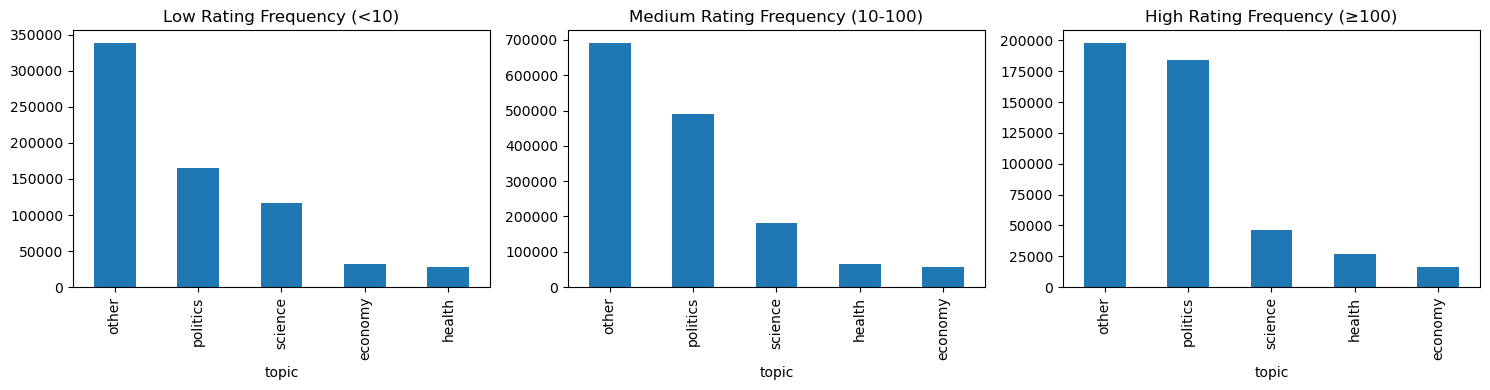

In [18]:
# boolean masks
mask_low = notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('raterParticipantId')['noteId'].transform('count') < 100) 
mask_high = notes_party.groupby('raterParticipantId')['noteId'].transform('count') >= 100

# topic counts by contribution frequency
topic_counts_low = notes_party[mask_low]['topic'].value_counts()
topic_counts_mid = notes_party[mask_mid]['topic'].value_counts()
topic_counts_high = notes_party[mask_high]['topic'].value_counts()

# bar plots of topic incidence for raters meeting each threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
topic_counts_low.plot.bar(ax=axes[0], title='Low Rating Frequency (<10)')
topic_counts_mid.plot.bar(ax=axes[1], title='Medium Rating Frequency (10-100)')
topic_counts_high.plot.bar(ax=axes[2], title='High Rating Frequency (≥100)')
plt.tight_layout()

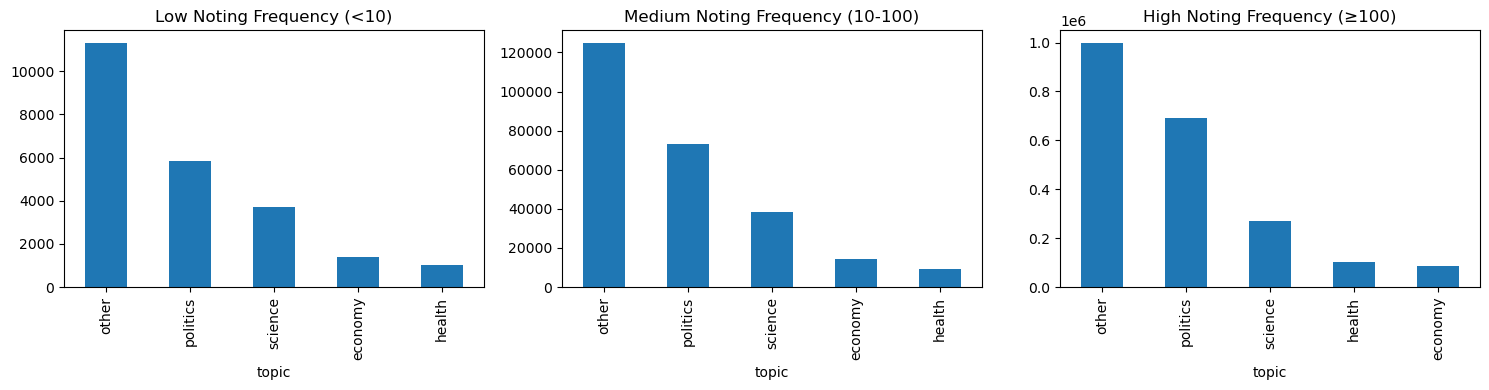

In [19]:
# boolean masks
mask_low = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') < 10
mask_mid = (notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') >= 10) & (notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') < 100) 
mask_high = notes_party.groupby('noteAuthorParticipantId')['noteId'].transform('count') >= 100

# topic counts by contribution frequency
topic_counts_low = notes_party[mask_low]['topic'].value_counts()
topic_counts_mid = notes_party[mask_mid]['topic'].value_counts()
topic_counts_high = notes_party[mask_high]['topic'].value_counts()

# bar plots of topic incidence for authors meeting each threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
topic_counts_low.plot.bar(ax=axes[0], title='Low Noting Frequency (<10)')
topic_counts_mid.plot.bar(ax=axes[1], title='Medium Noting Frequency (10-100)')
topic_counts_high.plot.bar(ax=axes[2], title='High Noting Frequency (≥100)')
plt.tight_layout()

### 7. What is the relationship between how frequently users contribute and their skill?

There appears to be a weak positive correlation between how frequently users write notes and the average final intercepts of their notes, indicating that writing notes increases a contributor's skill. Perhaps counterintuitively, this relationship is reversed for frequent note-*raters* - as the total number of notes a contributor has rated increases, the percentage of those ratings which ends up aligning with the final status of the note *decreases*. 

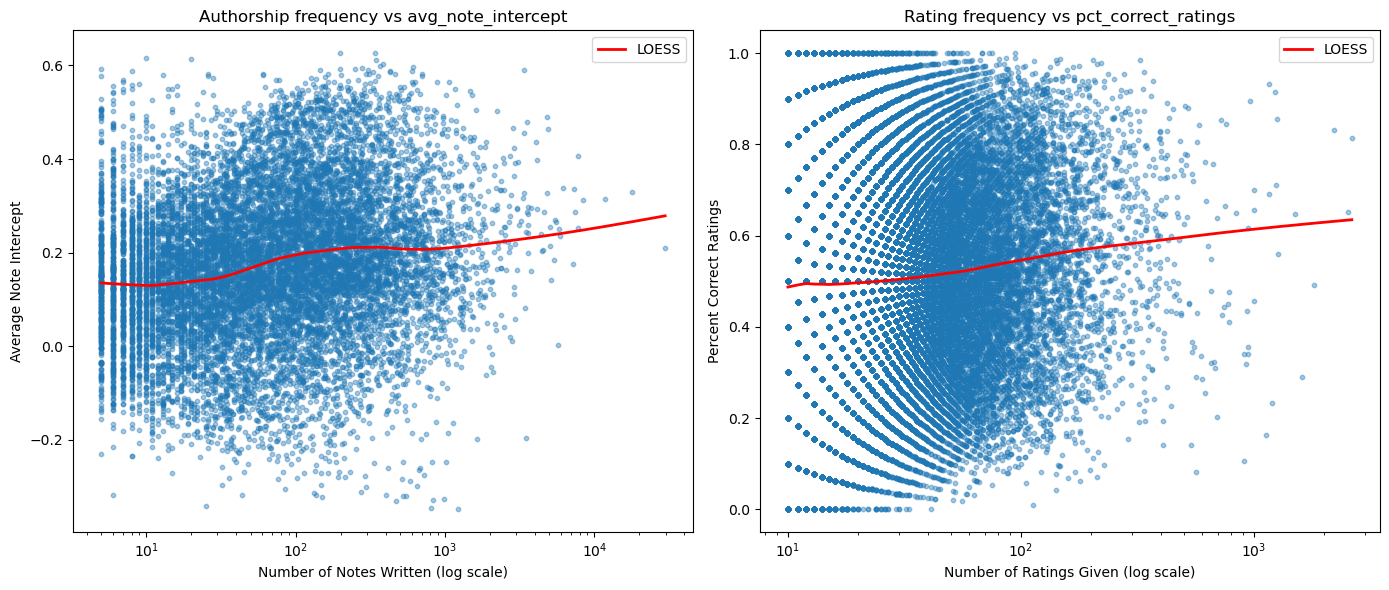

In [25]:
# Prepare data for authorship frequency vs avg_note_intercept
authors_mask = freq_noted >= 5
x_auth = freq_noted[authors_mask]
y_auth = notes_party.groupby('noteAuthorParticipantId')['noteFinalIntercept'].mean()[authors_mask.index[authors_mask]]

df_auth = pd.DataFrame({'freq': x_auth, 'avg_intercept': y_auth}).dropna()

# Prepare data for rating frequency vs pct_correct_ratings
raters_mask = freq_rated >= 10
x_rate = freq_rated[raters_mask]
y_rate = pct_correct_ratings[raters_mask.index[raters_mask]]

df_rate = pd.DataFrame({'freq': x_rate, 'pct_correct': y_rate}).dropna()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Authorship frequency vs avg_note_intercept
axes[0].scatter(df_auth['freq'], df_auth['avg_intercept'], s=10, alpha=0.4)

# LOESS curve for authors
log_freq_auth = np.log(df_auth['freq'].values)
smooth_auth = lowess(df_auth['avg_intercept'].values, log_freq_auth, frac=0.3, it=0, return_sorted=True)
axes[0].plot(np.exp(smooth_auth[:, 0]), smooth_auth[:, 1], color='red', lw=2, label='LOESS')

axes[0].set_xscale('log')
axes[0].set_xlabel('Number of Notes Written (log scale)')
axes[0].set_ylabel('Average Note Intercept')
axes[0].set_title('Authorship frequency vs avg_note_intercept')
axes[0].legend()

# Rating frequency vs pct_correct_ratings
axes[1].scatter(df_rate['freq'], df_rate['pct_correct'], s=10, alpha=0.4)

# LOESS curve for raters
log_freq_rate = np.log(df_rate['freq'].values)
smooth_rate = lowess(df_rate['pct_correct'].values, log_freq_rate, frac=0.3, it=0, return_sorted=True)
axes[1].plot(np.exp(smooth_rate[:, 0]), smooth_rate[:, 1], color='red', lw=2, label='LOESS')

axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Ratings Given (log scale)')
axes[1].set_ylabel('Percent Correct Ratings')
axes[1].set_title('Rating frequency vs pct_correct_ratings')
axes[1].legend()

plt.tight_layout()
plt.show()

### misc

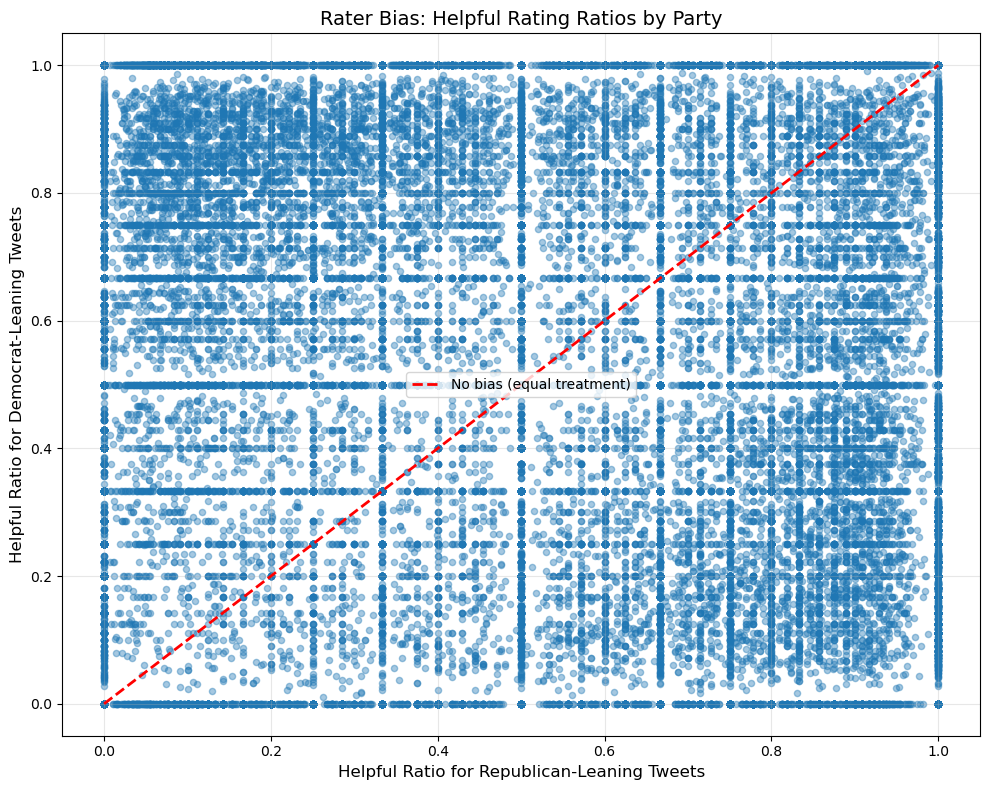

Mean bias (Democrat helpful ratio - Republican helpful ratio): 0.002
Std dev of bias: 0.550
Raters with >20% bias towards Democrats: 33575 (31.1%)
Raters with >20% bias towards Republicans: 33622 (31.2%)


In [ ]:
# Calculate rating frequencies by party for each rater
rater_party_counts = notes_party.groupby(['raterParticipantId', 'party', 'helpfulnessLevel']).size().unstack(fill_value=0)

# For each rater, calculate the ratio of helpful to not helpful ratings for each party
# Focus on raters who have rated both parties
raters_both_parties = notes_party.groupby('raterParticipantId')['party'].nunique()
raters_both_parties = raters_both_parties[raters_both_parties >= 2].index

# Filter data for raters who rated both parties
filtered_data = notes_party[notes_party['raterParticipantId'].isin(raters_both_parties)].copy()

# Calculate helpful vs not helpful for each party
helpful_by_party = filtered_data[filtered_data['helpfulnessLevel'] == 'HELPFUL'].groupby(['raterParticipantId', 'party']).size()
not_helpful_by_party = filtered_data[filtered_data['helpfulnessLevel'] == 'NOT_HELPFUL'].groupby(['raterParticipantId', 'party']).size()

# Create dataframe with these counts
party_rating_df = pd.DataFrame({
    'helpful': helpful_by_party,
    'not_helpful': not_helpful_by_party
}).fillna(0)

# Calculate the helpful ratio for each party
party_rating_df['helpful_ratio'] = party_rating_df['helpful'] / (party_rating_df['helpful'] + party_rating_df['not_helpful'])

# Pivot to get republican vs democrat for each rater
helpful_ratio_pivot = party_rating_df['helpful_ratio'].unstack(fill_value=np.nan)

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot points where raters have ratings for both parties
mask = (~helpful_ratio_pivot[-1.0].isna()) & (~helpful_ratio_pivot[1.0].isna())
data_plot = pd.DataFrame({
    'republican': helpful_ratio_pivot.loc[mask, -1.0],
    'democrat': helpful_ratio_pivot.loc[mask, 1.0]
}).dropna()

ax.scatter(data_plot['republican'], data_plot['democrat'], alpha=0.4, s=20)

# Add diagonal line (no bias)
ax.plot([0, 1], [0, 1], 'r--', lw=2, label='No bias (equal treatment)')

# Add labels and formatting
ax.set_xlabel('Helpful Ratio for Republican-Leaning Tweets', fontsize=12)
ax.set_ylabel('Helpful Ratio for Democrat-Leaning Tweets', fontsize=12)
ax.set_title('Rater Bias: Helpful Rating Ratios by Party', fontsize=14)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate bias metric
bias = data_plot['democrat'] - data_plot['republican']
print(f"Mean bias (Democrat helpful ratio - Republican helpful ratio): {bias.mean():.3f}")
print(f"Std dev of bias: {bias.std():.3f}")
print(f"Raters with >20% bias towards Democrats: {(bias > 0.2).sum()} ({(bias > 0.2).sum()/len(bias)*100:.1f}%)")
print(f"Raters with >20% bias towards Republicans: {(bias < -0.2).sum()} ({(bias < -0.2).sum()/len(bias)*100:.1f}%)")